## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime
import einops
from torch import nn
import torch as t
from typing import List
from jaxtyping import Float, Int
from tyche.inductive_bias import *

import itertools
import plotly.graph_objs as go  # Import the graph objects from Plotly
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
import pandas as pd
from tyche.estimator import VolumeConfig, VolumeEstimator

/home/louis/tyche/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = t.device("cuda:7" if t.cuda.is_available() else "cpu")
t.set_default_device(device)

In [10]:
import os
import torch as t
import einops
import plotly.graph_objects as go


def plot_indicator_table(model, params, save=False):
    device = next(model.parameters()).device
    N = params.N
    group_set = [[i, j, (i + j) % N] for i in range(N) for j in range(N)]
    inputs = t.tensor([g[:2] for g in group_set], dtype=t.long).to(device)

    with t.no_grad():
        model.eval()
        logits = model(inputs)  # shape N^2 x N
        max_prob_entry = t.argmax(logits, dim=-1)  # shape N^2

    output_matrix = einops.rearrange(max_prob_entry, "(n m) -> n m", n=N)  # shape N x N
    hover_labels = [[f"{output_matrix[j][i]}" for i in range(N)] for j in range(N)]
    row_labels = [str(g) for g in range(N)]
    col_labels = row_labels

    # Generate N different colors for the heatmap
    import plotly.colors as pc

    # Using a colorscale that works well for categorical data
    if N <= 10:
        # For small N, use distinct colors from the Plotly qualitative colorscales
        colors = pc.qualitative.Plotly[:N]
    else:
        # For larger N, generate a continuous colorscale with N distinct colors
        colorscale = pc.sequential.Viridis
        colors = [pc.sample_colorscale(colorscale, i / (N - 1))[0] for i in range(N)]

    # Create the colorscale with proper scaling between 0 and 1
    custom_colorscale = []
    for i in range(N):
        # Lower bound for this color
        custom_colorscale.append([i / N, colors[i]])
        # Upper bound for this color (except for the last color)
        if i < N - 1:
            custom_colorscale.append([(i + 1) / N, colors[i]])

    fig = go.Figure(
        data=go.Heatmap(
            z=output_matrix.tolist(),
            showscale=False,
            colorscale=custom_colorscale,
            x=col_labels,
            y=row_labels,
            zmin=0,
            zmax=N - 1,
            customdata=hover_labels,
            hovertemplate="x=%{x}<br>"
            + "y=%{y}<br>"
            + "z=%{customdata}<extra></extra>",
        ),
    )

    fig.update_layout(
        title=f"Final run",
        xaxis={
            "showgrid": True,
            "side": "top",
            "ticks": "outside",
            "tickmode": "array",
            "tickvals": [i for i in range(N)],
            "ticktext": row_labels,
        },
        yaxis={
            "showgrid": True,
            # "autorange": "reversed",
            "side": "left",
            "ticks": "outside",
            "tickmode": "array",
            "tickvals": [i for i in range(N)],
            "ticktext": col_labels,
        },
        height=900,
        width=900,
    )

    if save:
        # Create plots directory if it doesn't exist
        if not os.path.exists("plots"):
            os.mkdir("plots")
        fig.write_html("./plots/plot_final.html")

    return fig

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from typing import Literal, List, Union, Dict, Tuple
import matplotlib.colors as mcolors


def generate_heatmaps(
    df: pd.DataFrame,
    weight_mode: str,
    stat_type: Literal["mean", "variance", "variance/mean"] = "mean",
    volume_stat: Literal["mean", "variance"] = "mean",
    figsize: Tuple[int, int] = (15, 10),
    cmap: str = "viridis",
) -> Figure:
    """
    Generate heatmaps for a given weight_mode using only matplotlib.

    Args:
        df: DataFrame with required columns: activation, num_additional_layers, W_amplitude,
            weight_mode, sample_id, and volume_estimates (which may contain None values)
        weight_mode: The weight_mode to filter the data by
        stat_type: The statistic to compute across sample_ids ('mean', 'variance', or 'variance/mean')
        volume_stat: The statistic to compute for volume_estimates ('mean' or 'variance')
        figsize: Figure size as (width, height)
        cmap: Colormap for the heatmaps

    Returns:
        The matplotlib figure containing the heatmaps
    """
    # Filter data by weight_mode
    df_filtered = df[df["weight_mode"] == weight_mode].copy()

    # Define a safe function to compute statistics that handles None values
    def safe_array_stat(arr, stat_type="mean"):
        if arr is None:
            return np.nan
        try:
            if stat_type == "mean":
                return np.mean(arr)
            else:  # variance
                return np.var(arr)
        except:
            return np.nan

    # Function to format numbers nicely
    def format_number(value):
        if np.isnan(value):
            return ""

        abs_value = abs(value)

        if abs_value == 0:
            return "0"
        elif abs_value < 0.001 or abs_value >= 10000:
            # Use scientific notation for very small or very large numbers
            return f"{value:.1e}"
        elif abs_value < 0.01:
            return f"{value:.4f}"
        elif abs_value < 0.1:
            return f"{value:.3f}"
        elif abs_value < 1:
            return f"{value:.2f}"
        elif abs_value < 10:
            return f"{value:.2f}"
        else:
            return f"{value:.1f}"

    # Get unique values for creating the grid
    preferred_order = [
        "ReLU",
        "GELU",
        "Tanh",
        "GaussianActivation",
        "ComplexMultiplication",
    ]
    unique_activations = df_filtered["activation"].unique()
    activations = [act for act in preferred_order if act in unique_activations]
    n_activations = len(activations)

    # Calculate subplot grid dimensions
    n_cols = 3  # Force a 3x2 grid
    n_rows = 2

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)

    # Get all possible x and y values across all activations for consistent grid
    all_x_values = sorted(df_filtered["num_additional_layers"].unique())
    all_y_values = sorted(df_filtered["W_amplitude"].unique())

    # Format W_amplitude labels consistently
    y_labels = [format_number(val) for val in all_y_values]

    # First pass: collect all data to determine global min/max for consistent color scaling
    all_data = []

    for activation in activations:
        # Filter by current activation
        df_act = df_filtered[df_filtered["activation"] == activation].copy()

        # Process data for heatmap
        # Calculate the appropriate statistic for volume_estimates, handling None values
        df_act.loc[:, "vol_stat"] = df_act["volume_estimates"].apply(
            lambda x: safe_array_stat(x, volume_stat)
        )

        # Drop rows with NaN values (resulting from None in volume_estimates)
        df_act = df_act.dropna(subset=["vol_stat"])

        # If no valid data remains after filtering, continue
        if len(df_act) == 0:
            continue

        # Group by num_additional_layers and W_amplitude and compute the specified statistic
        grouped = df_act.groupby(["num_additional_layers", "W_amplitude"])["vol_stat"]

        if stat_type == "mean":
            agg_data = grouped.mean()
        elif stat_type == "variance":
            agg_data = grouped.var()
        elif stat_type == "variance/mean":
            mean_data = grouped.mean()
            var_data = grouped.var()
            # Avoid division by zero
            valid_indices = mean_data != 0
            agg_data = pd.Series(np.nan, index=mean_data.index)
            agg_data[valid_indices] = np.abs(
                var_data[valid_indices] / mean_data[valid_indices]
            )

        # Collect all values for global min/max
        all_data.extend(agg_data.values)

    # Determine global min/max for consistent color scaling
    if all_data:
        vmin = np.nanmin(all_data)
        vmax = np.nanmax(all_data)
    else:  # Handle case where no valid data at all
        vmin, vmax = 0, 1

    # Second pass: create heatmaps with consistent color scaling
    for i, activation in enumerate(activations):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]

        # Filter by current activation
        df_act = df_filtered[df_filtered["activation"] == activation].copy()

        # Process data for heatmap
        df_act.loc[:, "vol_stat"] = df_act["volume_estimates"].apply(
            lambda x: safe_array_stat(x, volume_stat)
        )

        # Drop rows with NaN values
        df_act = df_act.dropna(subset=["vol_stat"])

        # If no valid data remains after filtering, display a message but keep the grid
        if len(df_act) == 0:
            # Create a blank grid with the same structure
            heatmap_data = np.full((len(all_y_values), len(all_x_values)), np.nan)
            masked_data = np.ma.masked_invalid(heatmap_data)
            im = ax.imshow(
                masked_data,
                cmap=cmap,
                aspect="auto",
                origin="upper",
                vmin=vmin,
                vmax=vmax,
            )

            # Add message
            ax.text(
                0.5,
                0.5,
                f"No valid data for activation: {activation}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

            # Set title, labels, and ticks
            ax.set_title(f"Activation: {activation}")
            ax.set_xlabel("num_additional_layers")
            ax.set_ylabel("W_amplitude")
            ax.set_xticks(range(len(all_x_values)))
            ax.set_yticks(range(len(all_y_values)))
            ax.set_xticklabels(all_x_values)
            ax.set_yticklabels(y_labels)
            continue

        # Group by num_additional_layers and W_amplitude and compute the specified statistic
        grouped = df_act.groupby(["num_additional_layers", "W_amplitude"])["vol_stat"]

        if stat_type == "mean":
            agg_data = grouped.mean()
        elif stat_type == "variance":
            agg_data = grouped.var()
        elif stat_type == "variance/mean":
            mean_data = grouped.mean()
            var_data = grouped.var()
            # Avoid division by zero
            valid_indices = mean_data != 0
            agg_data = pd.Series(np.nan, index=mean_data.index)
            agg_data[valid_indices] = np.abs(
                var_data[valid_indices] / mean_data[valid_indices]
            )

        # Always use the global x and y values
        heatmap_data = np.full((len(all_y_values), len(all_x_values)), np.nan)

        # Fill the array with the aggregated values
        for (layer, amp), value in agg_data.items():
            if layer in all_x_values and amp in all_y_values:  # Make sure indices exist
                x_idx = all_x_values.index(layer)
                y_idx = all_y_values.index(amp)
                heatmap_data[y_idx, x_idx] = value

        # Create a masked array to handle NaN values
        masked_data = np.ma.masked_invalid(heatmap_data)

        # Create the heatmap with masked data and consistent vmin/vmax
        im = ax.imshow(
            masked_data, cmap=cmap, aspect="auto", origin="upper", vmin=vmin, vmax=vmax
        )

        # Add value annotations to the heatmap (only for non-NaN values)
        for y_idx, y_val in enumerate(all_y_values):
            for x_idx, x_val in enumerate(all_x_values):
                value = heatmap_data[y_idx, x_idx]
                if not np.isnan(value):
                    # Format values nicely
                    formatted_value = format_number(value)

                    # Determine text color based on background brightness
                    text_color = "white" if value > (vmin + vmax) / 2 else "black"
                    ax.text(
                        x_idx,
                        y_idx,
                        formatted_value,
                        ha="center",
                        va="center",
                        color=text_color,
                    )

        # Set title and labels
        ax.set_title(f"Activation: {activation}")
        ax.set_xlabel("num_additional_layers")
        ax.set_ylabel("W_amplitude")

        # Set ticks - use the global values for all plots
        ax.set_xticks(range(len(all_x_values)))
        ax.set_yticks(range(len(all_y_values)))
        ax.set_xticklabels(all_x_values)
        ax.set_yticklabels(y_labels)

    # Remove any unused subplots
    for i in range(n_activations, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        if row < len(axes) and col < len(axes[0]):  # Check if index is valid
            fig.delaxes(axes[row, col])

    # Add a single colorbar for all subplots
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax)

    # Add overall title
    volume_stat_name = "Mean" if volume_stat == "mean" else "Variance"
    if stat_type == "mean":
        stat_name = "Mean"
    elif stat_type == "variance":
        stat_name = "Variance"
    elif stat_type == "variance/mean":
        stat_name = "Variance / Mean"

    fig.suptitle(
        f"{volume_stat_name} Volume Estimates - {stat_name} across sample_ids\nWeight Mode: {weight_mode}",
        fontsize=16,
    )

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar and title

    return fig

## Evaluating hyperparameter search

In [26]:
WEIGHT_MODES = ["uniform", "xavier_uniform", "normal", "xavier_normal", "constant"]

In [48]:
path = "/home/louis/tyche/scripts/shared_database.parquet"
df = pd.read_parquet(path)

In [39]:
df["activation"].unique()

array(['Tanh', 'GaussianActivation', 'ReLU', 'GELU',
       'ComplexMultiplication'], dtype=object)

/tmp/ipykernel_212760/755310697.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar and title
/tmp/ipykernel_212760/755310697.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar and title
/tmp/ipykernel_212760/755310697.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar and title
/tmp/ipykernel_212760/755310697.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar and title
/tmp/ipykernel_212760/755310697.py:283: UserWarning: This figure include

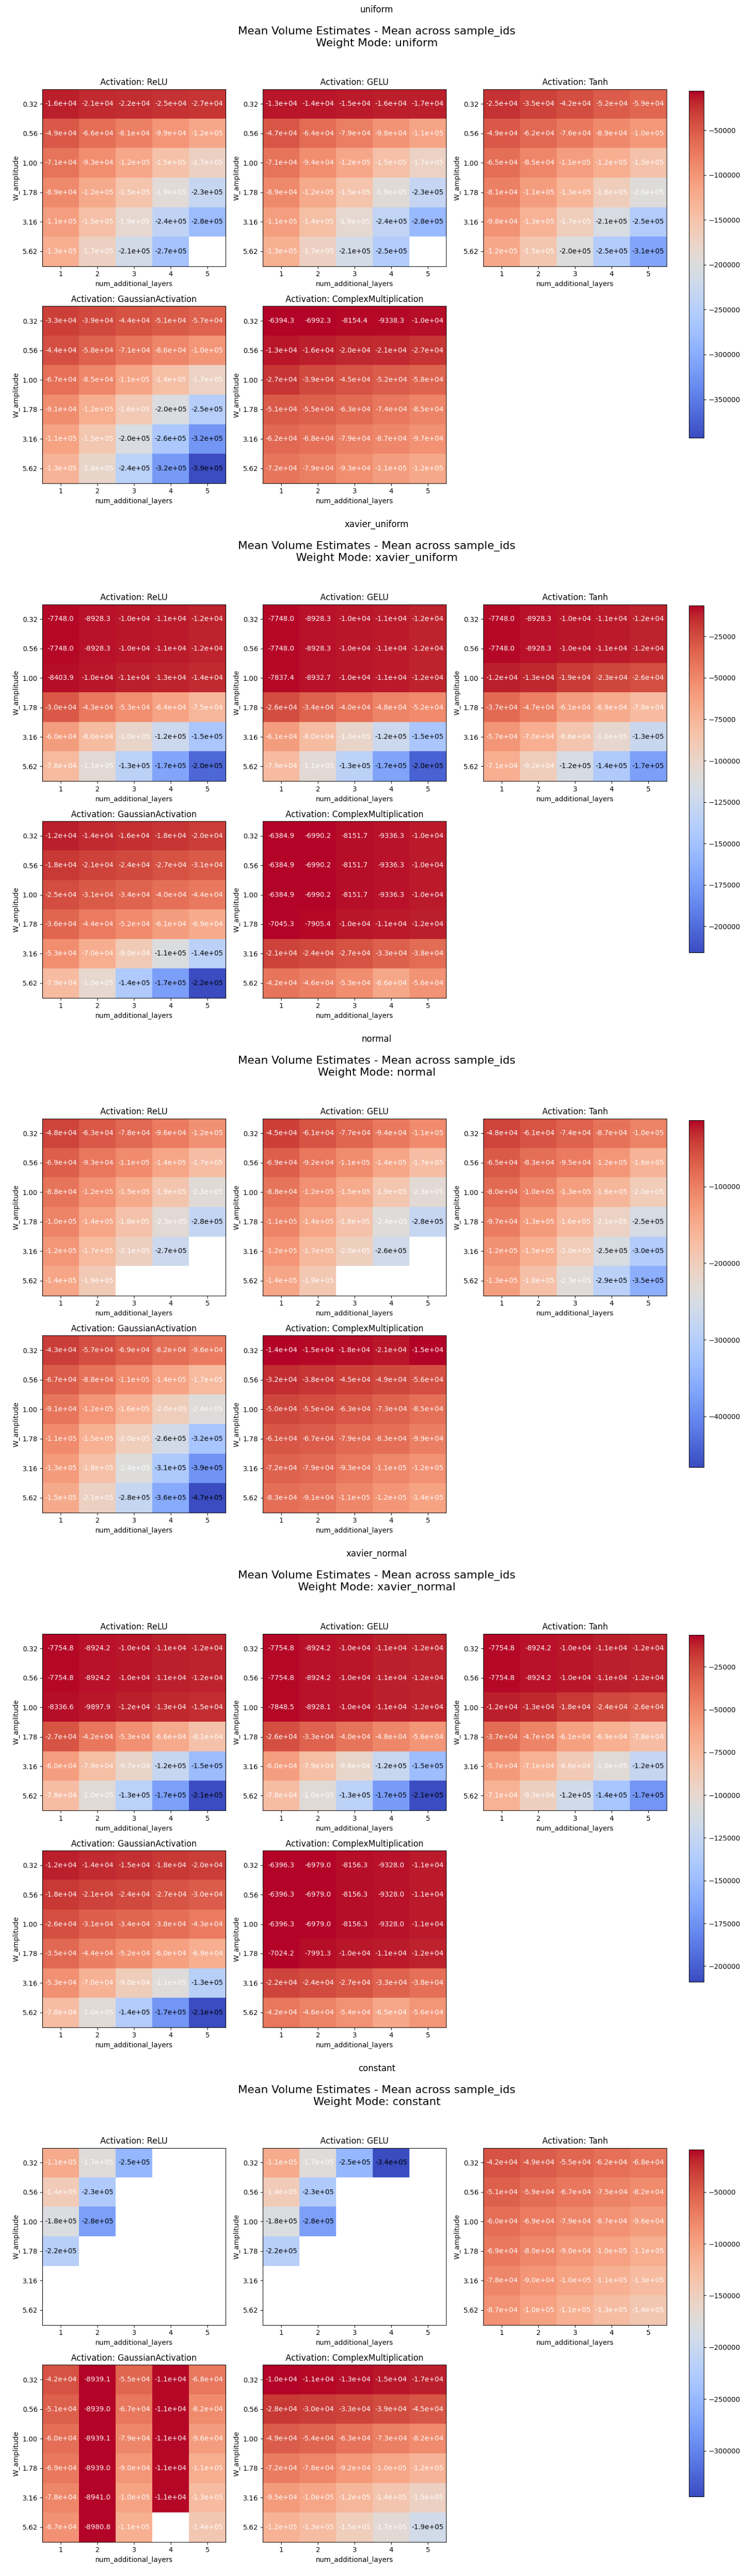

In [68]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io
from PIL import Image
import numpy as np

# Assuming df and WEIGHT_MODES are defined

num_weight_modes = len(WEIGHT_MODES)
num_activations = 5  # Assuming generate_heatmaps produces a plot with 5 heatmaps

# Determine the layout of the combined image grid
num_rows = num_weight_modes
num_cols = 1  # You can adjust this for a different arrangement

# Create the combined figure
fig_combined = plt.figure(figsize=(15 * num_cols, 10 * num_rows))
gs = gridspec.GridSpec(num_rows, num_cols)

for i, weight_mode in enumerate(WEIGHT_MODES):
    # Call generate_heatmaps to create the plot
    fig_individual = generate_heatmaps(
        df=df,
        weight_mode=weight_mode,
        stat_type="mean",
        volume_stat="mean",
        cmap="coolwarm",
    )

    # Save the individual figure to a BytesIO object (in-memory)
    buf = io.BytesIO()
    fig_individual.savefig(buf, format="png")
    buf.seek(0)
    img = Image.open(buf)
    img_array = np.array(img)
    plt.close(fig_individual)  # Close the individual figure

    # Add the image to the combined figure
    row = i // num_cols
    col = i % num_cols
    ax = fig_combined.add_subplot(gs[row, col])
    ax.imshow(img_array)
    ax.axis("off")  # Turn off axis labels and ticks
    ax.set_title(WEIGHT_MODES[i])

plt.tight_layout()
plt.show()

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


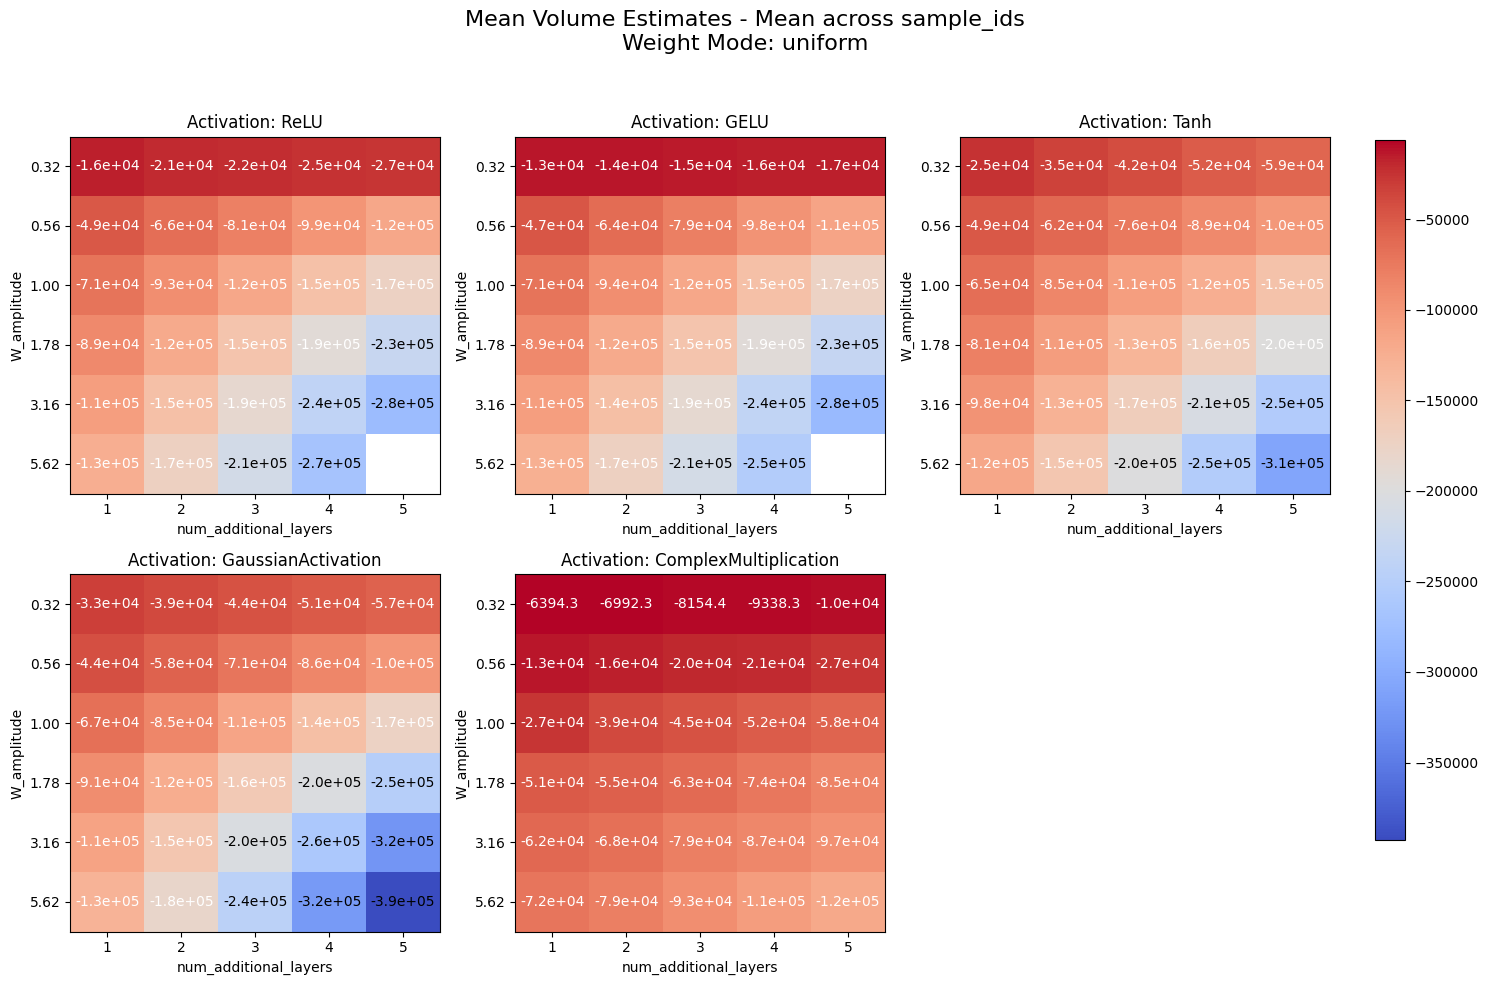

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


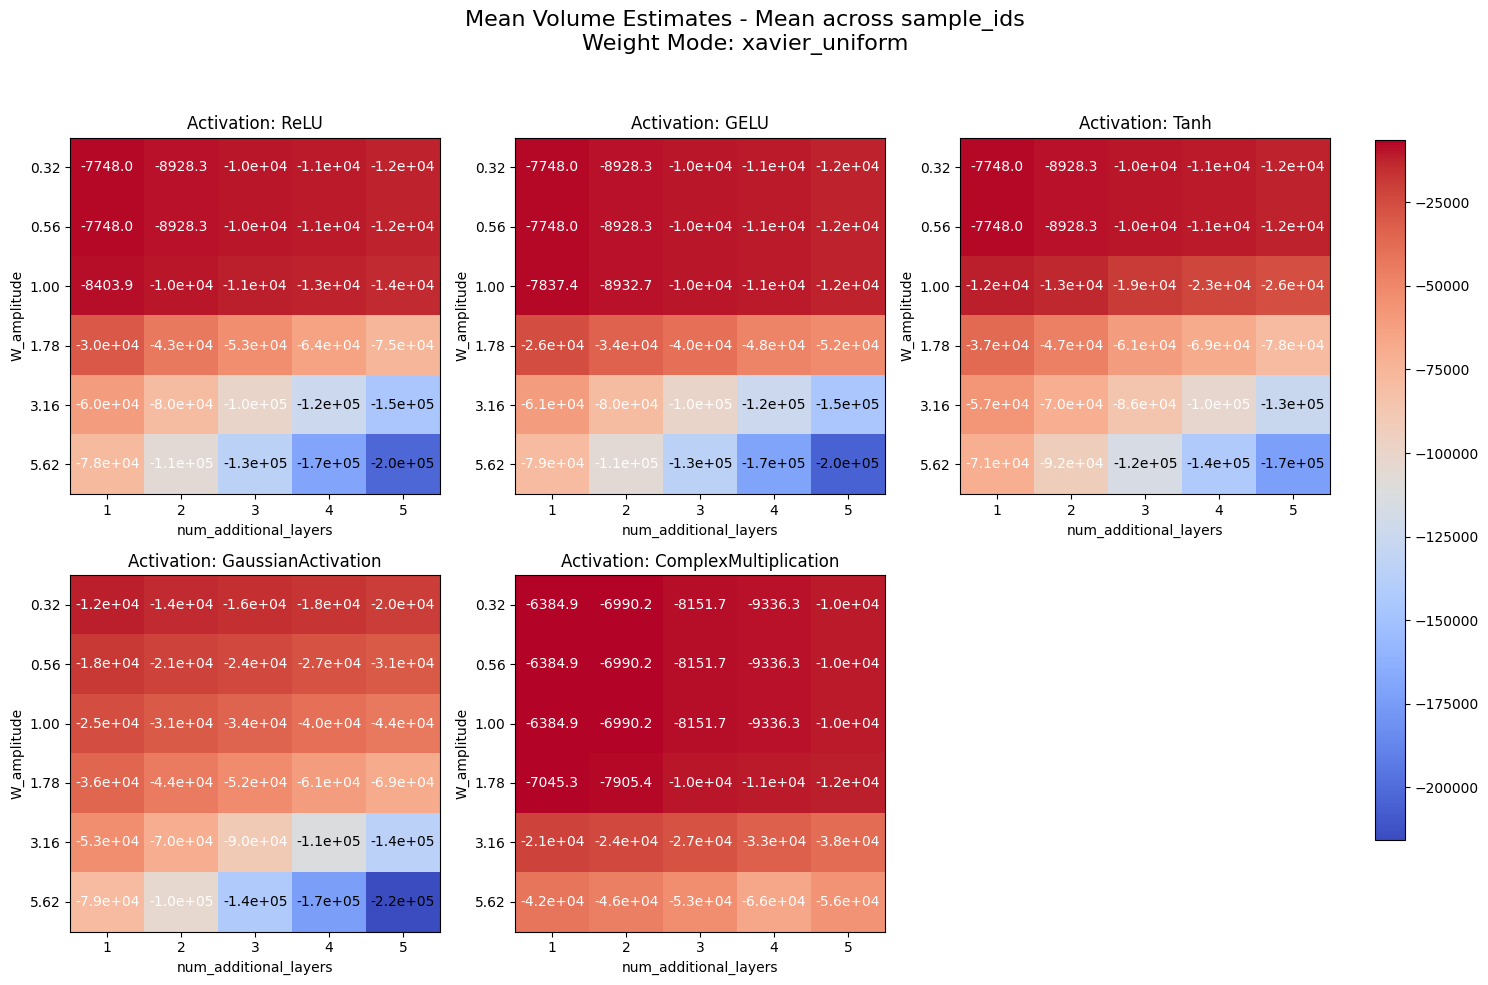

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


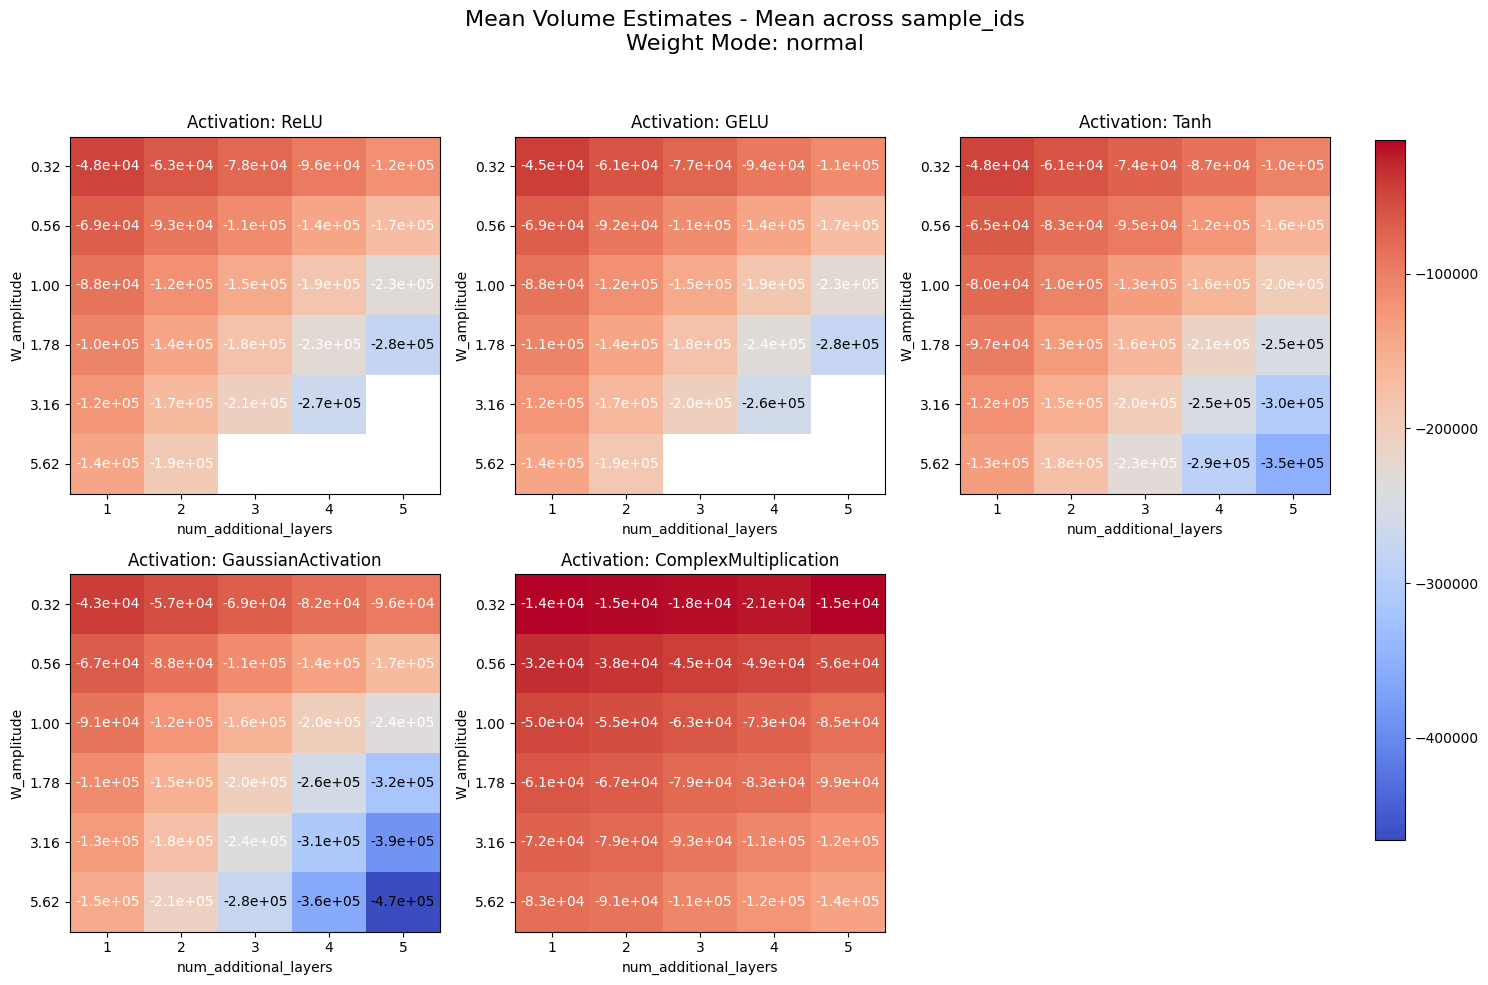

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


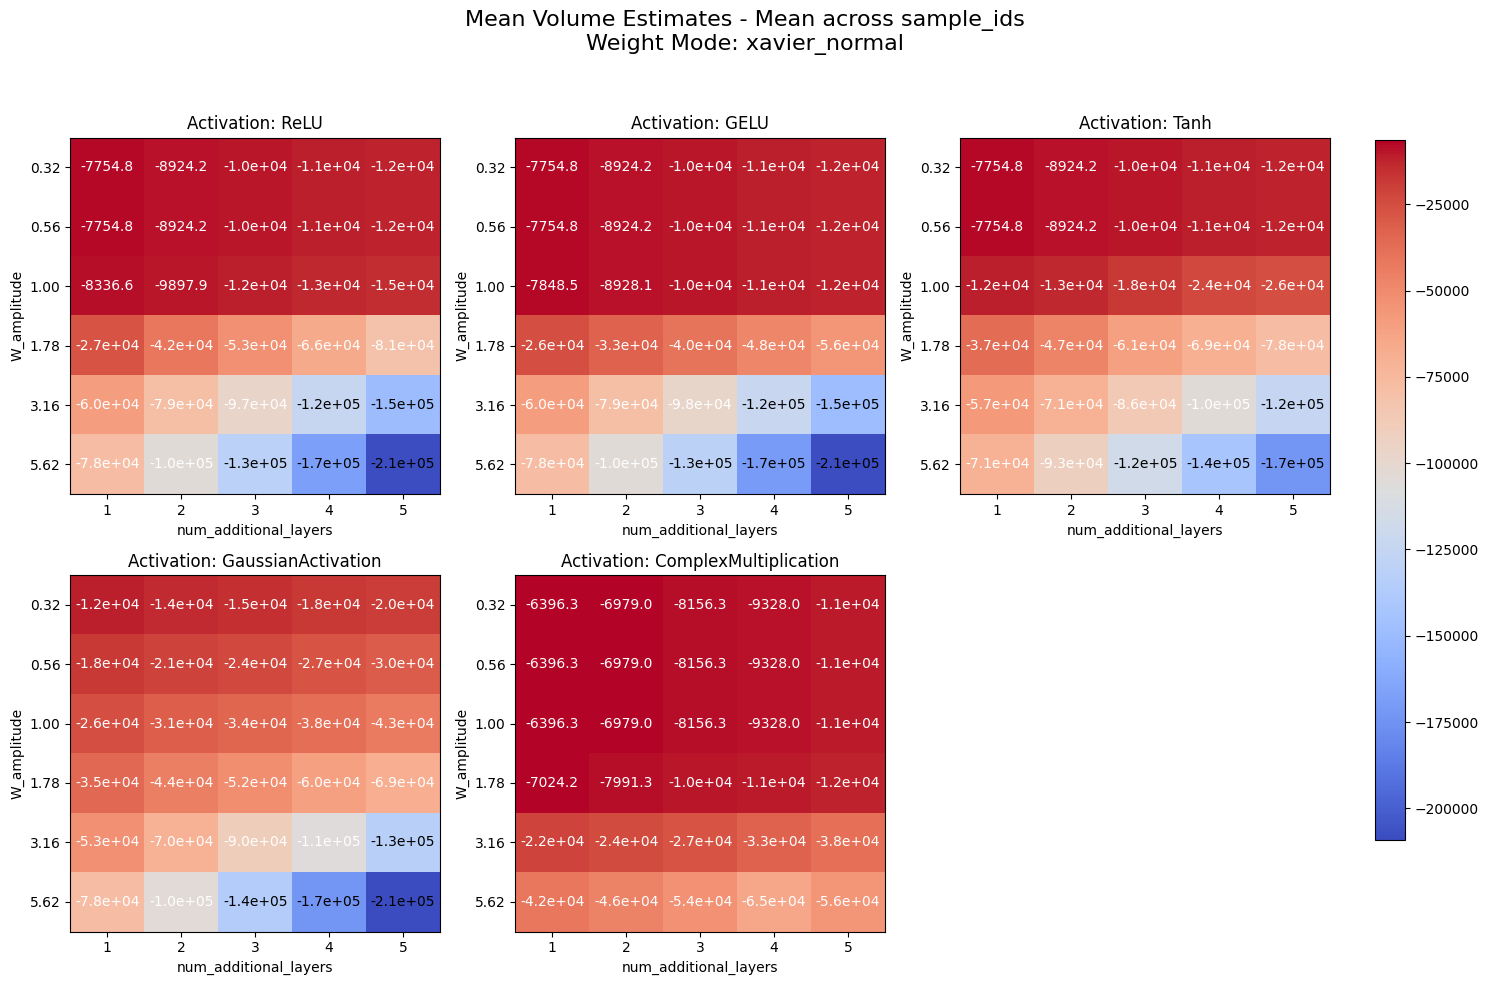

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


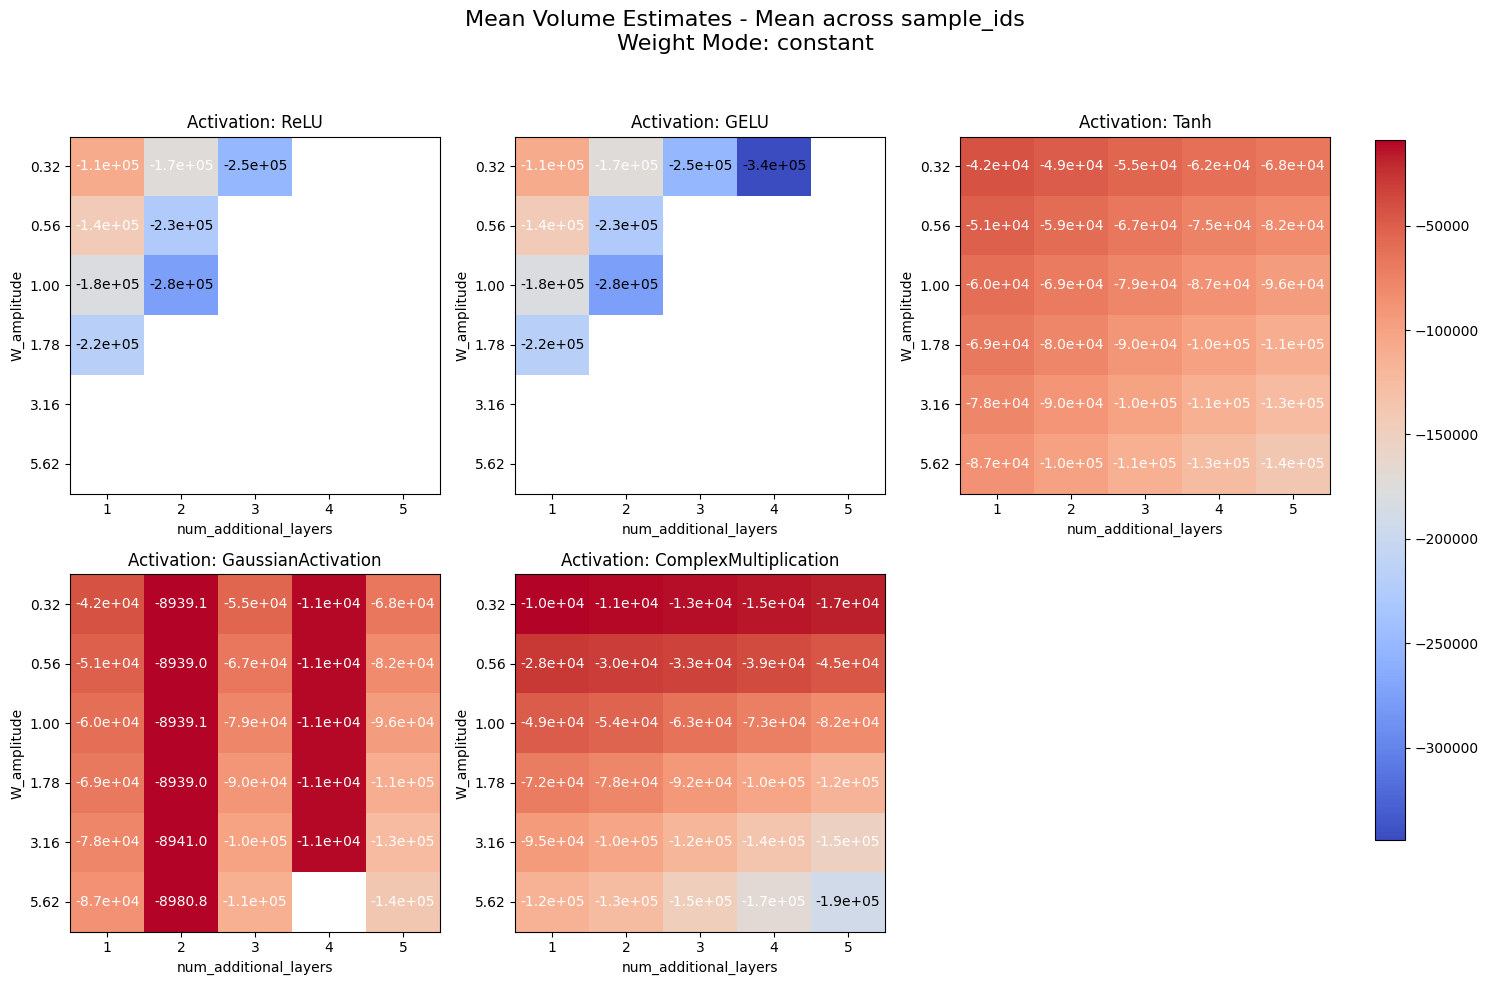

In [49]:
for weight_mode in WEIGHT_MODES:
    fig1 = generate_heatmaps(
        df,
        weight_mode=weight_mode,
        stat_type="mean",
        volume_stat="mean",
        cmap="coolwarm",
    )
    plt.show()

## training attempt

In [1]:
d = {"as": 2, "cell_type": "code", "execution_count": 0, "metadata": {}, "outputs": []}

In [8]:
type("sr") is str

True